In [169]:
# !pip install scikit-image

In [170]:
import numpy as np
import random
import matplotlib.pyplot as plt
from skimage import io, color
from skimage.transform import resize

# **Question 5 - Genetic Algorithm for Jigsaw Puzzle Solving**

This notebook implements a Genetic Algorithm (GA) that automatically assembles a jigsaw puzzle using:
- Tournament selection (k = 3)
- Kernel-Based Crossover
- Swap mutation
- Elite preservation
- Pixel-based edge similarity scoring (mean squared error)

Puzzle pieces are represented as small image patches with 4 edges (top, right, bottom, left).  
The GA evolves permutations of puzzle pieces to reconstruct the correct arrangement.

## Load Puzzle Image and Generate Pieces

We begin by loading a puzzle image, splitting it into equal-size rectangular pieces, and extracting the boundary pixel arrays for all four edges of each piece.

Each piece stores:
- its image patch
- top edge
- bottom edge
- left edge
- right edge

The default constructed **puzzle size is 3\*3**

In [171]:
img = io.imread('image.jpg')  
img = resize(img, (360, 360))

rows, cols = 9, 9
H, W = img.shape[0] // rows, img.shape[1] // cols

pieces = []
for i in range(rows):
    for j in range(cols):
        patch = img[i*H:(i+1)*H, j*W:(j+1)*W]
        patch_gray = color.rgb2gray(patch)

        pieces.append({
            'img': patch,
            'top': patch_gray[0, :],
            'bottom': patch_gray[-1, :],
            'left': patch_gray[:, 0],
            'right': patch_gray[:, -1]
        })

num_pieces = len(pieces)
print("Loaded", num_pieces, "pieces.")


Loaded 81 pieces.


## Edge Compatibility Scoring Function

We use Mean Squared Difference (MSD) between boundary pixel arrays.

A higher score means a better match, so we negate the MSE:

In [172]:
def edge_fit(e1, e2):
    return -np.mean((e1 - e2)**2)

fit_table = np.zeros((num_pieces, num_pieces, 2))

for i in range(num_pieces):
    for j in range(num_pieces):

        # right(i) matches left(j)
        fit_table[i, j, 0] = edge_fit(pieces[i]['right'], pieces[j]['left'])

        # bottom(i) matches top(j)
        fit_table[i, j, 1] = edge_fit(pieces[i]['bottom'], pieces[j]['top'])


## Puzzle Fitness Function

Given a chromosome (a permutation of piece indices), we reshape it into a grid and compute the total adjacency score:

- Horizontal matches: right edge of (i,j) with left edge of (i,j+1)
- Vertical matches: bottom edge of (i,j) with top edge of (i+1,j)

Higher fitness = better puzzle assembly.

In [173]:
def puzzle_fitness(chromosome):
    grid = np.array(chromosome).reshape(rows, cols)
    score = 0

    for i in range(rows):
        for j in range(cols):

            me = grid[i, j]

            # horizontal neighbors
            if j+1 < cols:
                right = grid[i, j+1]
                score += fit_table[me, right, 0]

            # vertical neighbors
            if i+1 < rows:
                bottom = grid[i+1, j]
                score += fit_table[me, bottom, 1]

    return score


## Tournament Selection


We randomly sample 3 individuals from the population and return the one with the highest fitness.


In [174]:
def tournament_selection(pop, fits, k=3):
    candidates = random.sample(range(len(pop)), k)
    best = max(candidates, key=lambda idx: fits[idx])
    return pop[best]


## Kernel-Based Crossover


This operator produces a valid permutation offspring from two parents.


In [175]:
def kernel_crossover(parent1, parent2):
    """
    Generate a child solution using adjacency-aware kernel crossover.
    parent1, parent2: permutations (lists) of piece indices
    Returns: child permutation (list of length 9)
    """
    # Convert parents to 2D grids
    grid1 = np.array(parent1).reshape(rows, cols)
    grid2 = np.array(parent2).reshape(rows, cols)
    
    # Child grid initialized with -1 (empty)
    child = -1 * np.ones((rows, cols), dtype=int)

    # Set of available pieces
    unused = set(range(num_pieces))

    # ---- 1. Pick a random root piece and place it in a random cell ----
    root_piece = random.choice(list(unused))
    unused.remove(root_piece)

    root_r = random.randint(0, rows-1)
    root_c = random.randint(0, cols-1)
    child[root_r, root_c] = root_piece

    # Frontier = list of positions adjacent to placed pieces
    frontier = [(root_r, root_c)]

    # ---- 2. Grow kernel until all pieces placed ----
    while unused:
        new_frontier = []
        
        for r, c in frontier:
            neighbors = []

            # List free neighbors
            if r > 0 and child[r-1, c] == -1: neighbors.append(('U', r-1, c))
            if r < rows-1 and child[r+1, c] == -1: neighbors.append(('D', r+1, c))
            if c > 0 and child[r, c-1] == -1: neighbors.append(('L', r, c-1))
            if c < cols-1 and child[r, c+1] == -1: neighbors.append(('R', r, c+1))

            for direction, rr, cc in neighbors:
                if child[rr, cc] != -1:
                    continue  # someone already placed it

                # ---- PRIORITY 1: parents agree on piece ----
                p1_piece = grid1[rr, cc]
                p2_piece = grid2[rr, cc]

                if p1_piece == p2_piece and p1_piece in unused:
                    chosen = p1_piece

                else:
                    # ---- PRIORITY 2: best match with neighbor piece ----
                    placed_piece = child[r, c]

                    best_fit = -1e18
                    chosen = None

                    for cand in list(unused):
                        # Compute fit depending on direction
                        if direction == 'U': fit = edge_fit(pieces[cand]['bottom'], pieces[placed_piece]['top'])
                        if direction == 'D': fit = edge_fit(pieces[cand]['top'], pieces[placed_piece]['bottom'])
                        if direction == 'L': fit = edge_fit(pieces[cand]['right'], pieces[placed_piece]['left'])
                        if direction == 'R': fit = edge_fit(pieces[cand]['left'], pieces[placed_piece]['right'])

                        if fit > best_fit:
                            best_fit = fit
                            chosen = cand

                # Place chosen piece
                child[rr, cc] = chosen
                unused.remove(chosen)
                new_frontier.append((rr, cc))

        frontier = new_frontier

    # Convert child grid back to linear chromosome
    return list(child.reshape(-1))


## Swap Mutation


With probability p, randomly swap two positions in the chromosome.

In [176]:
def mutate(chrom, p=0.1):
    if random.random() < p:
        i, j = random.sample(range(len(chrom)), 2)
        chrom[i], chrom[j] = chrom[j], chrom[i]
    return chrom


## Genetic Algorithm Main Loop

We implement:
- Population initialization
- Fitness evaluation
- Tournament selection
- PMX crossover
- Swap mutation
- Elitism
- Termination after fixed generations

In [ ]:
def genetic_algorithm(generations=20, pop_size=90, elite_size=2):
    population = [random.sample(range(num_pieces), num_pieces) 
                  for _ in range(pop_size)]

    for gen in range(generations):

        fitnesses = [puzzle_fitness(ch) for ch in population]
        new_pop = []

        elite_idx = np.argsort(fitnesses)[-elite_size:]
        for idx in elite_idx:
            new_pop.append(population[idx])
        

        while len(new_pop) < pop_size:
            p1 = tournament_selection(population, fitnesses, k=3)
            p2 = tournament_selection(population, fitnesses, k=3)
            child = kernel_crossover(p1, p2)
            child = mutate(child, 0.1)
            new_pop.append(child)

        population = new_pop

        if gen % 10 == 0:
            print(f"Gen {gen}: best fitness = {max(fitnesses):.4f}")

    fitnesses = [puzzle_fitness(ch) for ch in population]
    best_idx = np.argmax(fitnesses)
    return population[best_idx], max(fitnesses)


## Run the Genetic Algorithm

In [178]:
best_solution, best_score = genetic_algorithm()
best_solution, best_score


Gen 0: best fitness = -12.2120
Gen 10: best fitness = -0.6869


([np.int64(0),
  np.int64(1),
  np.int64(2),
  np.int64(3),
  np.int64(4),
  np.int64(5),
  np.int64(6),
  np.int64(7),
  np.int64(8),
  np.int64(9),
  np.int64(10),
  np.int64(11),
  np.int64(12),
  np.int64(13),
  np.int64(14),
  np.int64(15),
  np.int64(16),
  np.int64(17),
  np.int64(18),
  np.int64(19),
  np.int64(20),
  np.int64(21),
  np.int64(22),
  np.int64(23),
  np.int64(24),
  np.int64(25),
  np.int64(26),
  np.int64(27),
  np.int64(28),
  np.int64(29),
  np.int64(30),
  np.int64(31),
  np.int64(32),
  np.int64(33),
  np.int64(34),
  np.int64(35),
  np.int64(36),
  np.int64(37),
  np.int64(38),
  np.int64(39),
  np.int64(40),
  np.int64(41),
  np.int64(42),
  np.int64(43),
  np.int64(44),
  np.int64(45),
  np.int64(46),
  np.int64(47),
  np.int64(48),
  np.int64(49),
  np.int64(50),
  np.int64(51),
  np.int64(52),
  np.int64(53),
  np.int64(54),
  np.int64(55),
  np.int64(56),
  np.int64(57),
  np.int64(58),
  np.int64(59),
  np.int64(60),
  np.int64(61),
  np.int64(62),
  

## Visualize Final Puzzle Arrangement


We draw the assembled puzzle from the best chromosome.


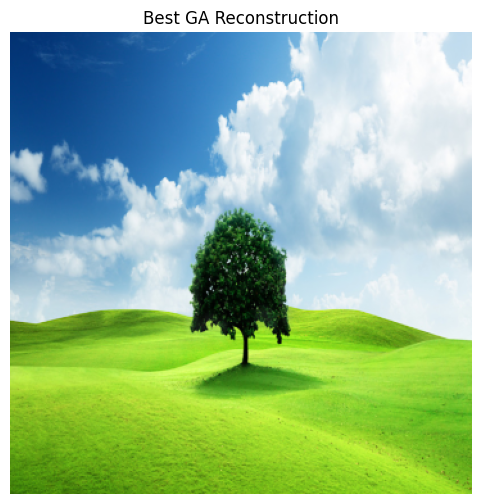

In [179]:
def visualize_solution(chrom):
    grid = np.array(chrom).reshape(rows, cols)
    out = np.zeros((rows*H, cols*W, 3))

    for i in range(rows):
        for j in range(cols):
            out[i*H:(i+1)*H, j*W:(j+1)*W] = pieces[grid[i,j]]['img']

    plt.figure(figsize=(6,6))
    plt.imshow(out.astype(float))
    plt.axis('off')
    plt.title("Best GA Reconstruction")
    plt.show()

visualize_solution(best_solution)

# **Question 12 - Rosenbrock Function: Gradient Descent vs. Newton's Method**

## Rosenbrock Definition

In [180]:
def f(x):
    x1, x2 = x
    return 100*(x2 - x1**2)**2 + (1-x1)**2

def grad_f(x):
    x1, x2 = x
    g1 = -400*x1*(x2 - x1**2) - 2*(1-x1)
    g2 = 200*(x2 - x1**2)
    return np.array([g1, g2])

def hessian_f(x):
    x1, x2 = x
    H = np.array([
        [1200*x1**2 - 400*x2 + 2, -400*x1],
        [-400*x1, 200]
    ])
    return H


## Gradient Descent

In [181]:
def gradient_descent(x0, alpha=0.001, max_iter=50):
    xs = [x0]
    fs = [f(x0)]
    x = x0.copy()
    for k in range(max_iter):
        g = grad_f(x)
        if np.linalg.norm(g) < 1e-6:
            break
        x = x - alpha*g
        xs.append(x)
        fs.append(f(x))
    return np.array(xs), np.array(fs)


## Newton's Method

In [182]:
def newton_method(x0, max_iter=50):
    xs = [x0]
    fs = [f(x0)]
    x = x0.copy()
    for k in range(max_iter):
        g = grad_f(x)
        if np.linalg.norm(g) < 1e-6:
            break
        H = hessian_f(x)
        p = -np.linalg.solve(H, g)
        x = x + p
        xs.append(x)
        fs.append(f(x))
    return np.array(xs), np.array(fs)


## Run Both Methods

In [183]:
x0 = np.array([-1.2, 1.0])

gd_path, gd_values = gradient_descent(x0)
newton_path, newton_values = newton_method(x0)


## Plot Trajectories on Contour Plot

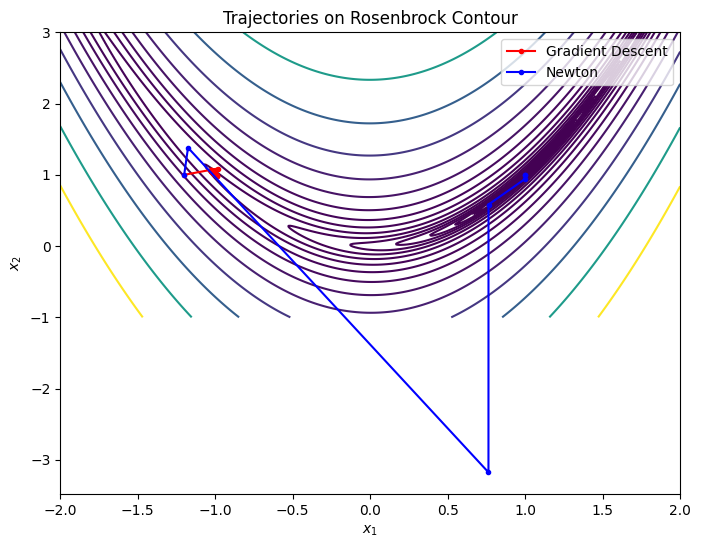

In [184]:
# Create contour grid
x1 = np.linspace(-2, 2, 400)
x2 = np.linspace(-1, 3, 400)
X1, X2 = np.meshgrid(x1, x2)
Z = 100*(X2 - X1**2)**2 + (1 - X1)**2

plt.figure(figsize=(8,6))
plt.contour(X1, X2, Z, levels=np.logspace(-2, 3, 20), cmap='viridis')
plt.plot(gd_path[:,0], gd_path[:,1], 'r.-', label='Gradient Descent')
plt.plot(newton_path[:,0], newton_path[:,1], 'b.-', label='Newton')
plt.legend()
plt.title("Trajectories on Rosenbrock Contour")
plt.xlabel("$x_1$")
plt.ylabel("$x_2$")
plt.show()


## Plot log f(xₖ) vs iteration

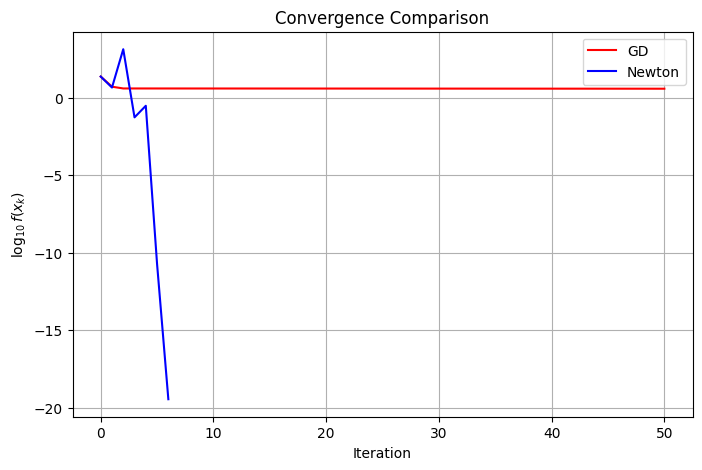

In [185]:
plt.figure(figsize=(8,5))
plt.plot(np.log10(gd_values), 'r-', label='GD')
plt.plot(np.log10(newton_values), 'b-', label='Newton')
plt.xlabel("Iteration")
plt.ylabel("$\log_{10} f(x_k)$")
plt.title("Convergence Comparison")
plt.legend()
plt.grid(True)
plt.show()


# **Question 13 - Equality-Constrained Optimization**

## Define F(w) and JF(w)

In [186]:
def F(w):
    x, y, lam = w
    S = np.exp(x**2 + y**2)
    return np.array([
        2*x*S + lam,
        2*y*S + lam,
        x + y - 1
    ])

def JF(w):
    x, y, lam = w
    S = np.exp(x**2 + y**2)
    return np.array([
        [2*S*(1 + 2*x**2), 4*x*y*S,        1],
        [4*x*y*S,         2*S*(1 + 2*y**2), 1],
        [1,               1,               0]
    ])


## Newton–Raphson Solver

In [187]:
def newton_system(w0, max_iter=20, tol=1e-10):
    w = w0.copy()
    ws = [w.copy()]
    for k in range(max_iter):
        Fw = F(w)
        if np.linalg.norm(Fw) < tol:
            break
        Jw = JF(w)
        step = np.linalg.solve(Jw, Fw)
        w = w - step
        ws.append(w.copy())
    return np.array(ws)


## Run From Initial Guess

In [189]:
w0 = np.array([0.0, 0.0, 0.0])
path = newton_system(w0)

print("Final solution:", path[-1])
print("Analytic solution:", np.array([0.5, 0.5, -np.exp(0.5)]))

Final solution: [ 0.5         0.5        -1.64872127]
Analytic solution: [ 0.5         0.5        -1.64872127]


# **Question 14 — Step-Size Strategies in Gradient Descent**

## Rosenbrock Definitions (same as before)

In [192]:
def f(x):
    x1, x2 = x
    return 100*(x2 - x1**2)**2 + (1-x1)**2

def grad_f(x):
    x1, x2 = x
    g1 = -400*x1*(x2 - x1**2) - 2*(1-x1)
    g2 = 200*(x2 - x1**2)
    return np.array([g1, g2])


## Backtracking Line Search (Armijo)

In [193]:
def backtracking_step(x, grad, alpha0=1.0, beta=0.5, c=1e-4):
    alpha = alpha0
    while f(x - alpha*grad) > f(x) - c * alpha * np.dot(grad, grad):
        alpha *= beta
    return alpha


## GD with Backtracking

In [194]:
def gd_backtracking(x0, max_iter=2000):
    x = x0.copy()
    xs = [x.copy()]
    fs = [f(x)]
    for k in range(max_iter):
        g = grad_f(x)
        if np.linalg.norm(g) < 1e-6:
            break
        alpha = backtracking_step(x, g)
        x = x - alpha * g
        xs.append(x.copy())
        fs.append(f(x))
    return np.array(xs), np.array(fs)


## GD with AdaGrad

In [195]:
def gd_adagrad(x0, eta=0.1, epsilon=1e-8, max_iter=2000):
    x = x0.copy()
    xs = [x.copy()]
    fs = [f(x)]
    G = np.zeros_like(x)
    for k in range(max_iter):
        g = grad_f(x)
        if np.linalg.norm(g) < 1e-6:
            break
        G += g*g
        adjusted_lr = eta / (np.sqrt(G) + epsilon)
        x = x - adjusted_lr * g
        xs.append(x.copy())
        fs.append(f(x))
    return np.array(xs), np.array(fs)


## Run Both Methods

In [196]:
x0 = np.array([-1.2, 1.0])

path_bt, vals_bt = gd_backtracking(x0)
path_ag, vals_ag = gd_adagrad(x0)

## Plot Trajectories

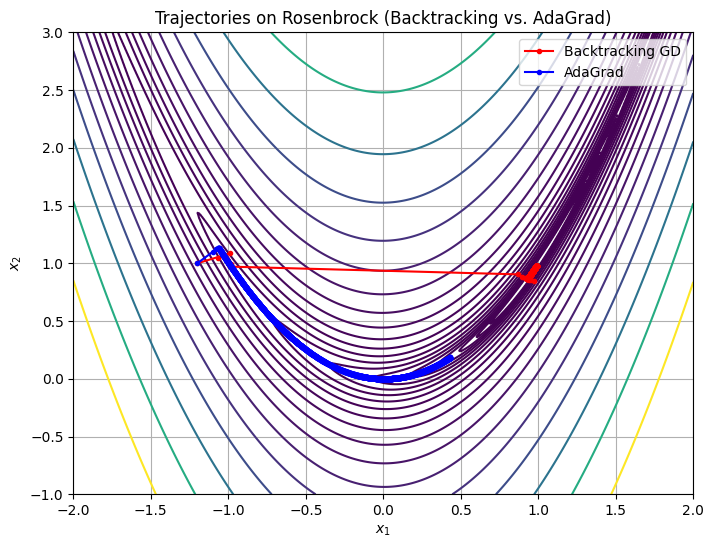

In [197]:
# contour
x1 = np.linspace(-2, 2, 400)
x2 = np.linspace(-1, 3, 400)
X1, X2 = np.meshgrid(x1, x2)
Z = 100*(X2 - X1**2)**2 + (1 - X1)**2

plt.figure(figsize=(8,6))
plt.contour(X1, X2, Z, levels=np.logspace(-1,3,20), cmap='viridis')

plt.plot(path_bt[:,0], path_bt[:,1], 'r.-', label='Backtracking GD')
plt.plot(path_ag[:,0], path_ag[:,1], 'b.-', label='AdaGrad')

plt.legend()
plt.xlabel("$x_1$")
plt.ylabel("$x_2$")
plt.title("Trajectories on Rosenbrock (Backtracking vs. AdaGrad)")
plt.grid(True)
plt.show()


## Plot Convergence Curves

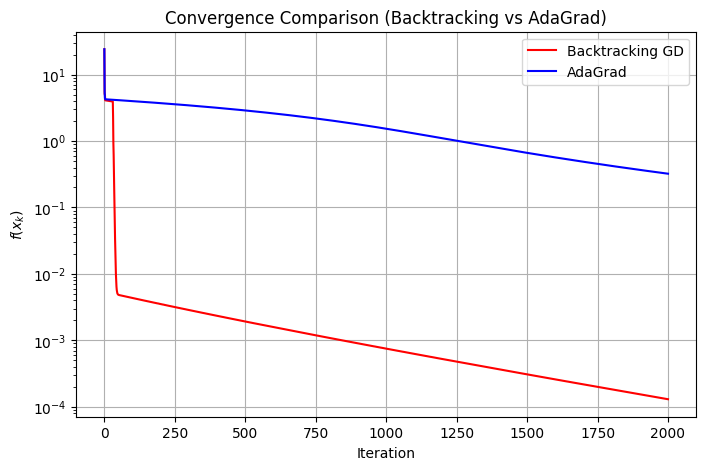

In [198]:
plt.figure(figsize=(8,5))
plt.semilogy(vals_bt, 'r-', label='Backtracking GD')
plt.semilogy(vals_ag, 'b-', label='AdaGrad')

plt.xlabel("Iteration")
plt.ylabel("$f(x_k)$")
plt.title("Convergence Comparison (Backtracking vs AdaGrad)")
plt.grid(True)
plt.legend()
plt.show()
